# Multi-Exit Dynamic Inference via PEFT (SST-2)

## Objective
To implement and benchmark a custom multi-exit transformer architecture for dynamic inference utilizing DistilRoBERTa. The study evaluates computational efficiency (FLOPs/latency) against accuracy degradation using Entropy and Energy-based gating mechanisms on the Stanford Sentiment Treebank (SST-2).

## Architecture Details
* **Base Encoder:** `distilroberta-base` (6 layers).
* **PEFT Method:** LoRA (Rank=8) applied to attention weight matrices (`query`, `value`).
* **Exit Topology:** Linear classification heads attached to intermediate hidden states (Layers 2, 4, 6).
* **Loss Function:** Uniformly weighted joint cross-entropy.

## Hardware Configuration
* **Environment:** Kaggle T4 GPU (16GB VRAM).
* **Memory Optimization:** Automatic Mixed Precision (AMP), LoRA, Gradient Accumulation.

In [13]:
!pip install -q transformers datasets peft accelerate evaluate fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## Phase 1: Environment and Hyperparameters
Configures the execution environment, initializes device parameters, and sets the hyperparameters for the SST-2 benchmark.

In [25]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel, AutoConfig
from datasets import load_dataset
from peft import LoraConfig, get_peft_model
import time
import numpy as np

# Hardware Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
MODEL_NAME = "distilbert-base-uncased"
TASK_NAME = "sst2" 
BATCH_SIZE = 32 
NUM_LABELS = 2
MAX_LEN = 128
# 0-indexed layers (DistilBERTa has 6 layers: 0 to 5). Exiting at layers 2, 4, 6.
EXIT_LAYERS = [1, 3, 5]

## Phase 2: Data Ingestion and Tokenization
Constructs the data pipeline for the SST-2 dataset. Implements single-sentence tokenization logic and formats the dataset into PyTorch tensors.

In [26]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def load_and_tokenize_sst2():
    dataset = load_dataset("glue", TASK_NAME)
    
    def tokenize_function(examples):
        return tokenizer(examples["sentence"], padding="max_length", truncation=True, max_length=MAX_LEN)

    tokenized_datasets = dataset.map(tokenize_function, batched=True)
    
    # Clean dataset for PyTorch DataLoader
    columns_to_remove = ["idx", "sentence"]
    existing_columns = tokenized_datasets["train"].column_names
    cols_to_drop = [col for col in columns_to_remove if col in existing_columns]
    
    tokenized_datasets = tokenized_datasets.remove_columns(cols_to_drop)
    tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
    tokenized_datasets.set_format("torch")
    
    return tokenized_datasets

tokenized_data = load_and_tokenize_sst2()
train_dataset = tokenized_data["train"]
eval_dataset = tokenized_data["validation"]

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

## Phase 3: Model Architecture Configuration
Constructs the custom multi-exit neural architecture. Applies LoRA to the base encoder for parameter-efficient training and instantiates fully trainable linear projection heads at designated intermediate layers.

In [27]:
class MultiExitDistilBert(nn.Module):
    def __init__(self, model_name, num_labels, exit_layers):
        super(MultiExitDistilBert, self).__init__()
        self.num_labels = num_labels
        self.exit_layers = exit_layers
        
        # 1. Load Base Model
        self.config = AutoConfig.from_pretrained(model_name)
        base_model = AutoModel.from_pretrained(model_name, config=self.config)
        
        # 2. Apply LoRA 
        lora_config = LoraConfig(
            r=8, 
            lora_alpha=16, 
            target_modules=["q_lin", "v_lin"], 
            lora_dropout=0.05, 
            bias="none", 
            task_type="FEATURE_EXTRACTION" 
        )
        self.encoder = get_peft_model(base_model, lora_config)
        
        # 3. Define Exit Heads (Fully Trainable)
        self.exits = nn.ModuleList([
            nn.Sequential(
                nn.Linear(self.config.hidden_size, self.config.hidden_size),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(self.config.hidden_size, num_labels)
            ) for _ in range(len(exit_layers))
        ])
        
        self.loss_fct = nn.CrossEntropyLoss()

    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        outputs = self.encoder(
            input_ids=input_ids, 
            attention_mask=attention_mask, 
            output_hidden_states=True
        )
        
        hidden_states = outputs.hidden_states
        logits_list = []
        total_loss = 0.0

        # Extract [CLS] token equivalent (index 0) from required layers
        for i, layer_idx in enumerate(self.exit_layers):
            layer_output = hidden_states[layer_idx + 1] 
            cls_output = layer_output[:, 0, :] 
            
            logits = self.exits[i](cls_output)
            logits_list.append(logits)
            
            if labels is not None:
                loss = self.loss_fct(logits.view(-1, self.num_labels), labels.view(-1))
                total_loss += loss

        if labels is not None:
            total_loss = total_loss / len(self.exit_layers)

        return {"loss": total_loss, "logits": logits_list}

model = MultiExitDistilBert(MODEL_NAME, NUM_LABELS, EXIT_LAYERS).to(device)
model.encoder.print_trainable_parameters()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 147,456 || all params: 66,510,336 || trainable%: 0.2217


## Phase 4: Joint Optimization
Executes the training phase utilizing PyTorch native AMP. The joint loss from all exits is backpropagated to update both the LoRA matrices and the custom classification heads.

In [28]:
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding
from torch.optim import AdamW
from tqdm.auto import tqdm
import gc

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_dataloader = DataLoader(
    train_dataset,
    shuffle=True, 
    batch_size=BATCH_SIZE, 
    collate_fn=data_collator
)

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-4)
scaler = torch.amp.GradScaler('cuda')

num_epochs = 5
model.train()

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    total_loss = 0
    
    progress_bar = tqdm(train_dataloader)
    for batch in progress_bar:
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            outputs = model(**batch)
            loss = outputs["loss"]
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        current_loss = loss.item()
        total_loss += current_loss
        progress_bar.set_postfix({'loss': f"{current_loss:.4f}"})
        
    print(f"Average Loss: {total_loss / len(train_dataloader):.4f}")

Epoch 1/5


  0%|          | 0/2105 [00:00<?, ?it/s]

Average Loss: 0.3131
Epoch 2/5


  0%|          | 0/2105 [00:00<?, ?it/s]

Average Loss: 0.2453
Epoch 3/5


...

Average Loss: 0.2146
Epoch 4/5


  0%|          | 0/2105 [00:00<?, ?it/s]

Average Loss: 0.1938
Epoch 5/5


  0%|          | 0/2105 [00:00<?, ?it/s]

Average Loss: 0.1770


## Phase 5: Dynamic Gating Logic
Defines mathematical criteria for early exiting (Shannon Entropy and Helmholtz Free Energy). Implements the dynamic inference loop capable of terminating computation sequences early.

In [29]:
import torch.nn.functional as F

def calculate_entropy(logits):
    probs = F.softmax(logits, dim=-1)
    entropy = -torch.sum(probs * torch.log(probs + 1e-9), dim=-1)
    return entropy

def calculate_energy(logits, temperature=1.0):
    energy = -temperature * torch.logsumexp(logits / temperature, dim=-1)
    return energy

def dynamic_inference(model, input_ids, attention_mask, threshold, gating_type="entropy"):
    model.eval()
    with torch.no_grad():
        outputs = model.encoder(
            input_ids=input_ids, 
            attention_mask=attention_mask, 
            output_hidden_states=True
        )
        hidden_states = outputs.hidden_states
        
        for i, layer_idx in enumerate(model.exit_layers):
            layer_output = hidden_states[layer_idx + 1]
            cls_output = layer_output[:, 0, :]
            logits = model.exits[i](cls_output)
            
            if gating_type == "entropy":
                metric = calculate_entropy(logits).item()
                confident = metric < threshold 
            elif gating_type == "energy":
                metric = calculate_energy(logits).item()
                confident = metric < threshold 
                
            if confident or i == len(model.exit_layers) - 1:
                prediction = torch.argmax(logits, dim=-1).item()
                return prediction, i + 1

## Phase 6: Sub-sample Benchmarking
Executes parameter sweeps across different threshold values for both gating mechanisms to measure predictive degradation versus exit depth.

In [30]:
def benchmark_gating_mechanism(model, eval_data, threshold, gating_type="entropy", num_samples=1000):
    correct = 0
    total_exit_depth = 0
    total_time = 0
    
    subset = eval_data.select(range(min(num_samples, len(eval_data))))
    
    for item in tqdm(subset, desc=f"Testing {gating_type.upper()} | Threshold: {threshold}"):
        input_ids = item["input_ids"].unsqueeze(0).to(device)
        attention_mask = item["attention_mask"].unsqueeze(0).to(device)
        label = item["labels"].item()
        
        start_time = time.perf_counter()
        pred, exit_level = dynamic_inference(model, input_ids, attention_mask, threshold, gating_type)
        total_time += (time.perf_counter() - start_time)
        
        if pred == label:
            correct += 1
        total_exit_depth += exit_level
        
    accuracy = correct / len(subset)
    avg_exit = total_exit_depth / len(subset)
    
    print(f"\n[Results] Gating: {gating_type.capitalize()} | Threshold: {threshold}")
    print(f"Accuracy:           {accuracy:.4f}")
    print(f"Average Exit Level: {avg_exit:.2f} (out of {len(model.exit_layers)})")
    print(f"Total Time:         {total_time:.2f} seconds\n")

# Sweep Examples
benchmark_gating_mechanism(model, eval_dataset, threshold=0.1, gating_type="entropy")
benchmark_gating_mechanism(model, eval_dataset, threshold=0.5, gating_type="entropy")
benchmark_gating_mechanism(model, eval_dataset, threshold=-1.5, gating_type="energy")

Testing ENTROPY | Threshold: 0.1:   0%|          | 0/872 [00:00<?, ?it/s]


[Results] Gating: Entropy | Threshold: 0.1
Accuracy:           0.8853
Average Exit Level: 1.90 (out of 3)
Total Time:         7.17 seconds



Testing ENTROPY | Threshold: 0.5:   0%|          | 0/872 [00:00<?, ?it/s]


[Results] Gating: Entropy | Threshold: 0.5
Accuracy:           0.8784
Average Exit Level: 1.26 (out of 3)
Total Time:         6.86 seconds



Testing ENERGY | Threshold: -1.5:   0%|          | 0/872 [00:00<?, ?it/s]


[Results] Gating: Energy | Threshold: -1.5
Accuracy:           0.8853
Average Exit Level: 1.65 (out of 3)
Total Time:         7.07 seconds



## Phase 7: Compute Matrices Extraction
Analyzes raw performance metrics. Estimates FLOP/MAC reductions based on average layer termination profiles against a full 6-layer baseline.

In [31]:
import pandas as pd

# DistilRoBERTa Sequence Length 128 Estimates
BASE_MACS = 5.5e9 

def comparative_analysis(model, eval_data, ent_thresh=0.5, eng_thresh=-1.5, num_samples=800):
    subset = eval_data.select(range(min(num_samples, len(eval_data))))
    total_samples = len(subset)
    
    metrics = {
        "Full Inference": {"correct": 0, "time": 0.0, "exits": []},
        "Dynamic (Entropy)": {"correct": 0, "time": 0.0, "exits": []},
        "Dynamic (Energy)": {"correct": 0, "time": 0.0, "exits": []}
    }
    
    model.eval()
    max_exits = len(model.exit_layers)
    
    # Warmup buffer
    dummy_input = subset[0]["input_ids"].unsqueeze(0).to(device)
    dummy_mask = subset[0]["attention_mask"].unsqueeze(0).to(device)
    _ = dynamic_inference(model, dummy_input, dummy_mask, threshold=0.5, gating_type="entropy")
    torch.cuda.synchronize()

    for item in tqdm(subset, desc="Running Comparative Benchmark"):
        input_ids = item["input_ids"].unsqueeze(0).to(device)
        attention_mask = item["attention_mask"].unsqueeze(0).to(device)
        label = item["labels"].item()
        
        # 1. Full Inference
        start = time.perf_counter()
        pred_full, exit_full = dynamic_inference(model, input_ids, attention_mask, threshold=-1.0, gating_type="entropy")
        torch.cuda.synchronize()
        metrics["Full Inference"]["time"] += (time.perf_counter() - start)
        if pred_full == label: metrics["Full Inference"]["correct"] += 1
        metrics["Full Inference"]["exits"].append(max_exits)
        
        # 2. Entropy
        start = time.perf_counter()
        pred_ent, exit_ent = dynamic_inference(model, input_ids, attention_mask, threshold=ent_thresh, gating_type="entropy")
        torch.cuda.synchronize()
        metrics["Dynamic (Entropy)"]["time"] += (time.perf_counter() - start)
        if pred_ent == label: metrics["Dynamic (Entropy)"]["correct"] += 1
        metrics["Dynamic (Entropy)"]["exits"].append(exit_ent)
        
        # 3. Energy
        start = time.perf_counter()
        pred_eng, exit_eng = dynamic_inference(model, input_ids, attention_mask, threshold=eng_thresh, gating_type="energy")
        torch.cuda.synchronize()
        metrics["Dynamic (Energy)"]["time"] += (time.perf_counter() - start)
        if pred_eng == label: metrics["Dynamic (Energy)"]["correct"] += 1
        metrics["Dynamic (Energy)"]["exits"].append(exit_eng)

    results = []
    for method, data in metrics.items():
        acc = data["correct"] / total_samples
        avg_time_ms = (data["time"] / total_samples) * 1000 
        avg_exit = sum(data["exits"]) / total_samples
        
        layer_ratio = avg_exit / max_exits
        est_macs = BASE_MACS * layer_ratio
        est_flops = est_macs * 2 
        
        results.append({
            "Inference Mode": method,
            "Accuracy (%)": f"{acc * 100:.2f}",
            "Time/Sample (ms)": f"{avg_time_ms:.2f}",
            "Avg Exit Level": f"{avg_exit:.2f} / {max_exits}",
            "Est. MACs (G)": f"{est_macs / 1e9:.2f}",
            "Est. FLOPs (G)": f"{est_flops / 1e9:.2f}"
        })
        
    return pd.DataFrame(results)

df_comparison = comparative_analysis(model, eval_dataset, ent_thresh=0.5, eng_thresh=-1.5)
display(df_comparison)

Running Comparative Benchmark:   0%|          | 0/800 [00:00<?, ?it/s]

,Inference Mode,Accuracy (%),Time/Sample (ms),Avg Exit Level,Est. MACs (G),Est. FLOPs (G)
0,Full Inference,88.00,8.64,3.00 / 3,5.50,11.00
1,Dynamic (Entropy),87.62,7.96,1.26 / 3,2.31,4.62
2,Dynamic (Energy),88.12,8.16,1.66 / 3,3.03,6.07


## Phase 8: Graphical Distribution
Visualizes the sequence termination frequency across the designated exit layers, comparing the behavior of Entropy vs. Energy routing.

Mapping Exit Distributions:   0%|          | 0/800 [00:00<?, ?it/s]

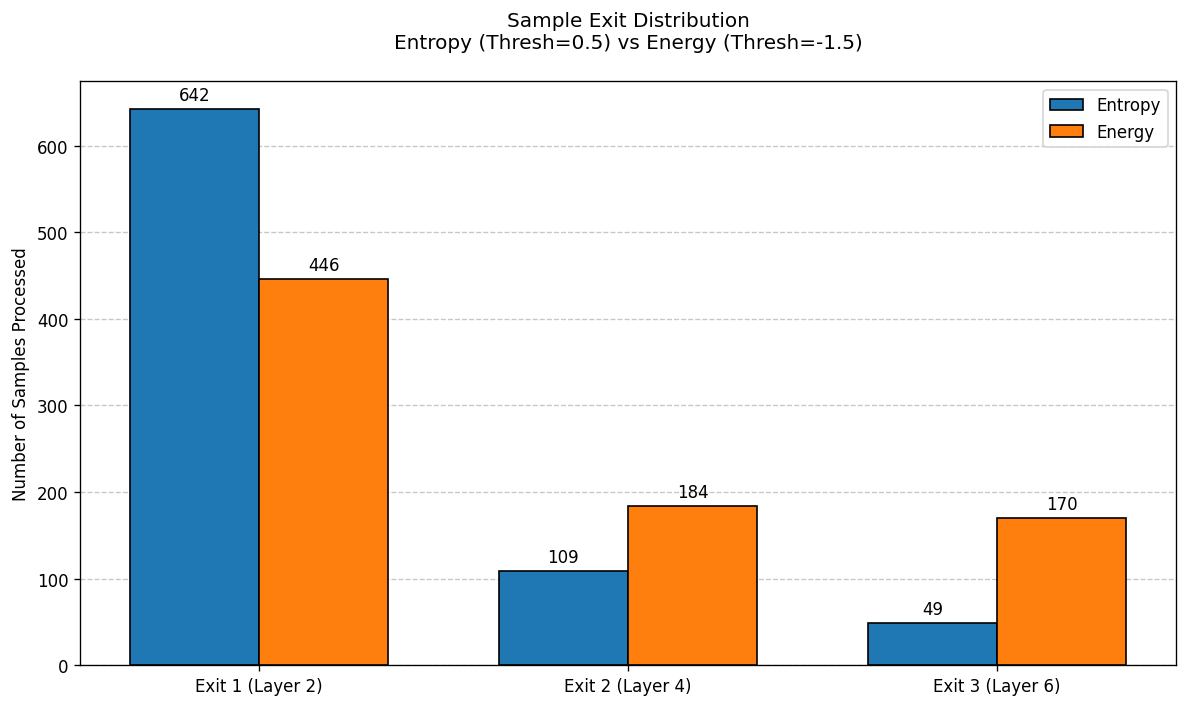

In [32]:
import matplotlib.pyplot as plt
from collections import Counter

def plot_exit_distribution(model, eval_data, ent_thresh=0.5, eng_thresh=-1.5, num_samples=800):
    subset = eval_data.select(range(min(num_samples, len(eval_data))))
    entropy_exits, energy_exits = [], []
    
    model.eval()
    for item in tqdm(subset, desc="Mapping Exit Distributions"):
        input_ids = item["input_ids"].unsqueeze(0).to(device)
        attention_mask = item["attention_mask"].unsqueeze(0).to(device)
        
        _, exit_ent = dynamic_inference(model, input_ids, attention_mask, threshold=ent_thresh, gating_type="entropy")
        entropy_exits.append(exit_ent)
        
        _, exit_eng = dynamic_inference(model, input_ids, attention_mask, threshold=eng_thresh, gating_type="energy")
        energy_exits.append(exit_eng)
        
    ent_counts = Counter(entropy_exits)
    eng_counts = Counter(energy_exits)
    
    num_exits = len(model.exit_layers)
    labels = [f"Exit {i+1} (Layer {model.exit_layers[i]+1})" for i in range(num_exits)]
    x = np.arange(len(labels))
    width = 0.35
    
    ent_values = [ent_counts.get(i+1, 0) for i in range(num_exits)]
    eng_values = [eng_counts.get(i+1, 0) for i in range(num_exits)]
    
    fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
    rects1 = ax.bar(x - width/2, ent_values, width, label='Entropy', color='#1f77b4', edgecolor='black')
    rects2 = ax.bar(x + width/2, eng_values, width, label='Energy', color='#ff7f0e', edgecolor='black')
    
    ax.set_ylabel('Number of Samples Processed')
    ax.set_title(f'Sample Exit Distribution\nEntropy (Thresh={ent_thresh}) vs Energy (Thresh={eng_thresh})', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    ax.bar_label(rects1, padding=3)
    ax.bar_label(rects2, padding=3)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
    
    fig.tight_layout()
    plt.show()

plot_exit_distribution(model, eval_dataset, ent_thresh=0.5, eng_thresh=-1.5)

## Phase 9: Output Serialization
Persists the trained model state dictionary and tokenizer configuration to the execution environment's local storage.

In [33]:
import os

SAVE_DIR = "./multi_exit_distilbert_sst2" 
os.makedirs(SAVE_DIR, exist_ok=True)

tokenizer.save_pretrained(SAVE_DIR)
print(f"Tokenizer saved to {SAVE_DIR}")

MODEL_PATH = os.path.join(SAVE_DIR, "model_state_dict.pth")
torch.save(model.cpu().state_dict(), MODEL_PATH)
print(f"Model weights successfully saved to {MODEL_PATH}")

model.to(device)

Tokenizer saved to ./multi_exit_distilbert_sst2
Model weights successfully saved to ./multi_exit_distilbert_sst2/model_state_dict.pth


MultiExitDistilBert(
  (encoder): PeftModelForFeatureExtraction(
    (base_model): LoraModel(
      (model): DistilBertModel(
        (embeddings): Embeddings(
          (word_embeddings): Embedding(30522, 768, padding_idx=0)
          (position_embeddings): Embedding(512, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (transformer): Transformer(
          (layer): ModuleList(
            (0-5): 6 x TransformerBlock(
              (attention): DistilBertSelfAttention(
                (q_lin): lora.Linear(
                  (base_layer): Linear(in_features=768, out_features=768, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.05, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=768, out_features=8, bias=False)
                  )
                  (lora_B): M

 ## Phase 10: Export Artifacts
Compresses the serialized parameters and instantiates a UI link to download the results from the Kaggle kernel.

In [35]:
import shutil
from IPython.display import FileLink

directory_to_zip = "./multi_exit_distilbert_sst2"
output_filename = "multi_exit_distilbert_sst2.zip"

shutil.make_archive(directory_to_zip.replace('./', ''), 'zip', directory_to_zip)
print(f"Successfully compressed {directory_to_zip} into {output_filename}")

display(FileLink(output_filename))

Successfully compressed ./multi_exit_distilbert_sst2 into multi_exit_distilbert_sst2.zip


/kaggle/working/multi_exit_distilbert_sst2.zip